# QR function

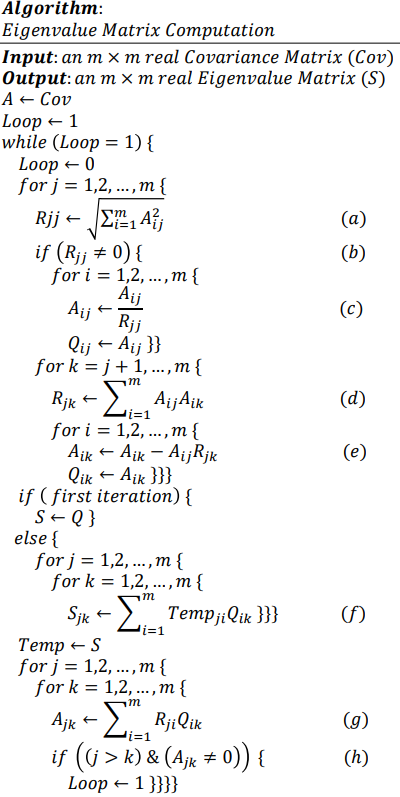

https://www.researchgate.net/publication/349850350_OPTIMIZED_EMBEDDED_AND_RECONFIGURABLE_HARDWARE_ARCHITECTURES_AND_TECHNIQUES_FOR_DATA_MINING_APPLICATIONS_ON_MOBILE_DEVICES 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math as m

In [2]:
def qr_factorization(Cov):
    A = Cov.astype(float).copy()
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    S = np.zeros((n, n))
    Loop = 1
    iter = 0

    while(Loop == 1):
        Loop = 0

        for j in range(m):

            v = A[:, j].copy() 
            R[j, j] = np.sqrt(np.sum(v**2))

            if R[j, j] != 0:
                for i in range(m):
                    Q[i, j] = v[i] / R[j, j]

            for k in range(j, m):
                R[j, k] = np.sum(Q[:, j] * A[:, k])

                for i in range(m):
                    A[i, k] = A[i, k] - (Q[i, j] * R[j, k])  

        if iter == 0:
            S = Q.copy()
        else:
            for j in range(m):
                for k in range(m):
                    S[j, k] = np.sum(Temp[j, :] * Q[:, k])

        Temp = S.copy()

        for j in range(m):
            for k in range(m):
                A[j, k] = np.sum(R[j, :] * Q[:, k])

                if ((j > k) and (abs(A[j, k]) > 1e-10)):  
                    Loop = 1

        iter += 1

    return Q, R, S

In [3]:
import numpy as np

A = np.array([[4, 1],
              [2, 3]], dtype=float)

Q, R, S = qr_factorization(A)

print("Q =")
print(Q)

print("\nR =")
print(R)

print("\nS (wektory własne) =")
print(S)

print("\nPrzybliżone wartości własne =")
print(np.diag(R @ Q))

Q =
[[ 1.00000000e+00 -2.02661776e-11]
 [ 2.02661983e-11  1.00000000e+00]]

R =
[[ 5. -1.]
 [ 0.  2.]]

S (wektory własne) =
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Przybliżone wartości własne =
[5. 2.]


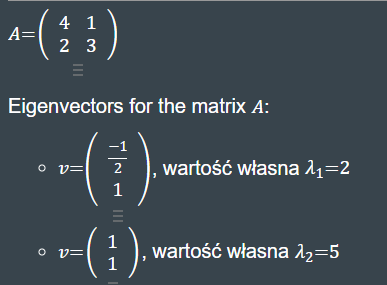